In [1]:
## import postgreSQL adapter for the Python
import psycopg2

In [2]:
conn = psycopg2.connect("host=127.0.0.1 dbname=stock_api user=postgres password=admin")

In [3]:
# ตัวส่งคำสั่งช่องทางเชื่อมDBSQLทุกSQLต้องผ่านcursorเท่านั้น
cur = conn.cursor()

In [4]:
#เช็กชื่อ Database ที่เชื่อมอยู่
cur.execute("SELECT current_database();")
print(cur.fetchone())

('stock_api',)


In [6]:
import psycopg2

conn = psycopg2.connect(
    host="127.0.0.1",
    dbname="stock_api",   #  DB ที่คุณใช้
    user="postgres",
    password="admin"
)

cur = conn.cursor()
print("Connected to stock_api!")

Connected to stock_api!


In [8]:
#สร้างตาราง stock_quotes
create_table_sql = """
CREATE TABLE IF NOT EXISTS stock_quotes (
    id BIGSERIAL PRIMARY KEY,
    symbol VARCHAR(20) NOT NULL,
    instrument_type VARCHAR(20),
    security_type VARCHAR(10),
    exchange VARCHAR(10),
    market_status VARCHAR(20),
    status VARCHAR(10),

    last_price NUMERIC(12,4),
    high_price NUMERIC(12,4),
    low_price NUMERIC(12,4),
    average_price NUMERIC(12,4),
    change_price NUMERIC(12,4),
    percent_change NUMERIC(8,4),

    total_volume BIGINT,
    buy_volume BIGINT,
    sell_volume BIGINT,
    no_side_volume BIGINT,

    eps NUMERIC(10,5),
    pe NUMERIC(10,4),
    pbv NUMERIC(10,4),
    percent_yield NUMERIC(8,4),

    created_at TIMESTAMP DEFAULT NOW()
);
"""

cur.execute(create_table_sql)
conn.commit()

print("Table stock_quotes created!")


Table stock_quotes created!


In [9]:
#ตรวจสอบ
cur.execute("""
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'public';
""")

cur.fetchall()

[('stock_quotes',)]

In [10]:
pip install settrade-v2

Note: you may need to restart the kernel to use updated packages.


In [11]:
#import และตั้งค่า Credential
from settrade_v2 import Investor
from pprint import pprint

In [14]:
## Settrade Sandbox Credentials
APP_ID = "K2JnAs0pc2Pzi1Pz"
APP_SECRET = "f3myG7DczEPZcE93KKayywR66NQugQ4VpSH0DkJcWxc="
BROKER_ID = "SANDBOX"
APP_CODE = "SANDBOX"

In [15]:
#ตรวจสอบ
investor = Investor(
    app_id=APP_ID,
    app_secret=APP_SECRET,
    broker_id=BROKER_ID,
    app_code=APP_CODE,
    is_auto_queue=False
)

print("API Connected")

API Connected


In [16]:
#เรียก Market Data
mkt_data = investor.MarketData()

In [17]:
# ดึงข้อมูลหุ้น AOT
quote = mkt_data.get_quote_symbol("AOT")

from pprint import pprint
pprint(quote)


{'aumSize': None,
 'average': 51.07905,
 'change': 3.0,
 'eps': 1.26877,
 'exchange': None,
 'exercisePrice': None,
 'exerciseRatio': None,
 'high': 53.0,
 'impliedVolatility': None,
 'inav': None,
 'instrumentType': 'STOCK',
 'intrinsicValue': None,
 'last': 53.0,
 'lastTradingDate': None,
 'low': 50.75,
 'marketStatus': 'Close',
 'maturityDate': None,
 'moneyness': None,
 'pbv': 5.78,
 'pe': 41.77,
 'percentChange': 6.0,
 'percentYield': 1.53,
 'securityType': 'CS',
 'status': '',
 'symbol': 'AOT',
 'theoretical': None,
 'toLastTrade': None,
 'totalBuyVolume': 40600,
 'totalNoSideVolume': 0,
 'totalSellVolume': 214300,
 'totalVolume': 254900,
 'underlying': None,
 'underlyingPrice': None}


In [28]:
#เช็คfuntion
dir(mkt_data)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_ctx',
 'get_candlestick',
 'get_quote_symbol',
 'market_url']

In [49]:
#สร้างdbใหม่2
cur.execute("""
CREATE TABLE IF NOT EXISTS stock_ohlc (
    id SERIAL PRIMARY KEY,
    symbol VARCHAR(10),
    time TIMESTAMP,
    open NUMERIC,
    high NUMERIC,
    low NUMERIC,
    close NUMERIC,
    volume BIGINT,
    value NUMERIC
);
""")

conn.commit()
print("Table stock_ohlc created successfully")


Table stock_ohlc created successfully


In [50]:
#กำหนด symbol และช่วงเวลา
TARGET_SYMBOL = "AOT"

from datetime import datetime, timedelta

end_date = datetime.today()
start_date = end_date - timedelta(days=365)

In [57]:
#market
from settrade_v2 import Investor

investor = Investor(
    app_id=APP_ID,
    app_secret=APP_SECRET,
    broker_id=BROKER_ID,
    app_code=APP_CODE,      #ต้องมี
    is_auto_queue=False
)

market = investor.MarketData()
print("MarketData ready")


MarketData ready


In [58]:
market

In [59]:
print("[PROCESSING] Fetching historical data...")

history = market.get_candlestick(
    symbol="AOT",
    interval="1d",
    limit=260,
    normalized=True
)

[PROCESSING] Fetching historical data...


In [60]:
#แปลงเป็น DataFrame
type(history)

dict

In [61]:
history.keys()

dict_keys(['lastSequence', 'time', 'open', 'high', 'low', 'close', 'volume', 'value'])

In [67]:
#แปลงเป็น DataFrame
import pandas as pd

df = pd.DataFrame({
    "time": history["time"],
    "open": history["open"],
    "high": history["high"],
    "low": history["low"],
    "close": history["close"],
    "volume": history["volume"],
    "value": history["value"]
})

df.head()

,time,open,high,low,close,volume,value
0,1734973200,60.0,60.25,59.50,60.00,12587522,0.0
1,1735059600,60.0,60.25,59.75,60.00,7177021,0.0
2,1735146000,60.0,60.25,59.75,59.75,5890778,0.0
3,1735232400,60.0,60.25,59.50,59.75,9772823,0.0
4,1735491600,60.0,60.75,59.50,59.50,17881101,0.0


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    260 non-null    int64  
 1   open    260 non-null    float64
 2   high    260 non-null    float64
 3   low     260 non-null    float64
 4   close   260 non-null    float64
 5   volume  260 non-null    int64  
 6   value   260 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 14.3 KB


In [69]:
#ตรวจสอบเเถว
len(df)

260

In [71]:
#แปลง time ให้เป็นวันที่
df["time"] = pd.to_datetime(df["time"], unit="s")
df.head()

,time,open,high,low,close,volume,value
0,2024-12-23 17:00:00,60.0,60.25,59.50,60.00,12587522,0.0
1,2024-12-24 17:00:00,60.0,60.25,59.75,60.00,7177021,0.0
2,2024-12-25 17:00:00,60.0,60.25,59.75,59.75,5890778,0.0
3,2024-12-26 17:00:00,60.0,60.25,59.50,59.75,9772823,0.0
4,2024-12-29 17:00:00,60.0,60.75,59.50,59.50,17881101,0.0


In [72]:
len(df)

260

In [74]:
#Insert ข้อมูลลง table stock_ohlc
for _, row in df.iterrows():
    cur.execute("""
        INSERT INTO stock_ohlc
        (symbol, time, open, high, low, close, volume, value)
        VALUES (%s,%s,%s,%s,%s,%s,%s,%s)
    """, (
        "AOT",
        row["time"],
        row["open"],
        row["high"],
        row["low"],
        row["close"],
        row["volume"],
        row["value"]
    ))

conn.commit()
print("Insert data success")

Insert data success


Matplotlib is building the font cache; this may take a moment.


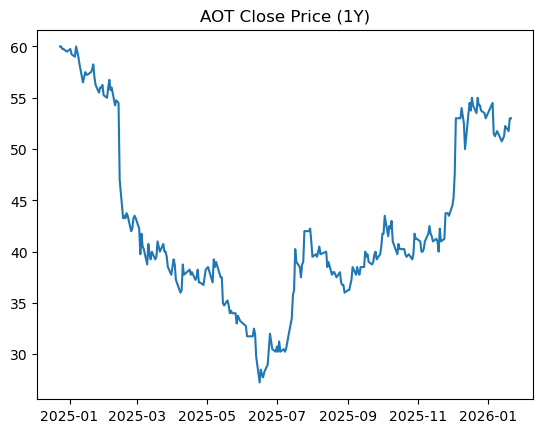

In [75]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["time"], df["close"])
plt.title("AOT Close Price (1Y)")
plt.show()


In [1]:
from settrade_v2 import Investor
from settrade_v2.market import MarketData
from datetime import datetime
import pandas as pd

In [20]:
from settrade_v2 import Investor

investor = Investor(
    app_id=APP_ID,
    app_secret=APP_SECRET,
    app_code="SANDBOX",
    broker_id="SANDBOX"
)


In [21]:
market = investor.MarketData()

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# สร้างวันที่ย้อนหลัง 1 ปี
dates = pd.date_range(end=pd.Timestamp.today(), periods=250)

# สร้างราคาจำลอง
price = np.cumsum(np.random.randn(250)) + 70

df = pd.DataFrame({
    "date": dates,
    "close": price
})


In [31]:
df.set_index("date", inplace=True)


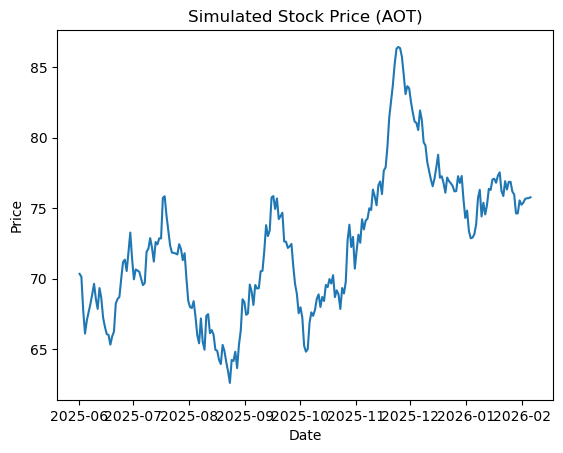

In [32]:
plt.figure()
plt.plot(df.index, df["close"])
plt.title("Simulated Stock Price (AOT)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()


In [33]:
import pandas as pd
import numpy as np

# สร้างวันที่ย้อนหลัง ~5 ปี
dates = pd.date_range(end=pd.Timestamp.today(), periods=1300, freq="B")

# สร้างข้อมูลหุ้นจำลอง
df = pd.DataFrame({
    "date": dates,
    "open": np.random.uniform(60, 70, size=len(dates)),
    "high": np.random.uniform(70, 75, size=len(dates)),
    "low": np.random.uniform(55, 60, size=len(dates)),
    "close": np.random.uniform(60, 70, size=len(dates)),
    "volume": np.random.randint(1_000_000, 5_000_000, size=len(dates))
})

df.head()


,date,open,high,low,close,volume
0,2021-02-12 11:23:26.454633,63.179198,71.766791,55.576344,61.693265,3598337
1,2021-02-15 11:23:26.454633,67.226091,73.254109,55.862138,63.235208,2261608
2,2021-02-16 11:23:26.454633,61.850888,72.662101,59.546060,65.166805,3749473
3,2021-02-17 11:23:26.454633,69.853629,74.545846,55.462904,66.065033,1819648
4,2021-02-18 11:23:26.454633,61.910071,74.848209,57.931612,69.346095,2061418


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1300 non-null   datetime64[ns]
 1   open    1300 non-null   float64       
 2   high    1300 non-null   float64       
 3   low     1300 non-null   float64       
 4   close   1300 non-null   float64       
 5   volume  1300 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 61.1 KB


In [35]:
df.describe()

,date,open,high,low,close,volume
count,1300,1300.000000,1300.000000,1300.000000,1300.000000,1.300000e+03
mean,2023-08-11 13:47:26.454632704,65.107784,72.444675,57.466120,64.964638,3.016762e+06
min,2021-02-12 11:23:26.454633,60.000741,70.000099,55.001356,60.011177,1.000294e+06
25%,2022-05-13 05:23:26.454632960,62.644123,71.234245,56.168581,62.439312,2.003072e+06
50%,2023-08-10 23:23:26.454632960,65.139167,72.485357,57.445456,65.039407,2.993730e+06
75%,2024-11-07 17:23:26.454632960,67.504053,73.617653,58.755089,67.428304,4.058600e+06
max,2026-02-05 11:23:26.454633,69.979583,74.990304,59.999974,69.981241,4.999221e+06
std,NaN,2.851999,1.414974,1.463962,2.875314,1.173254e+06


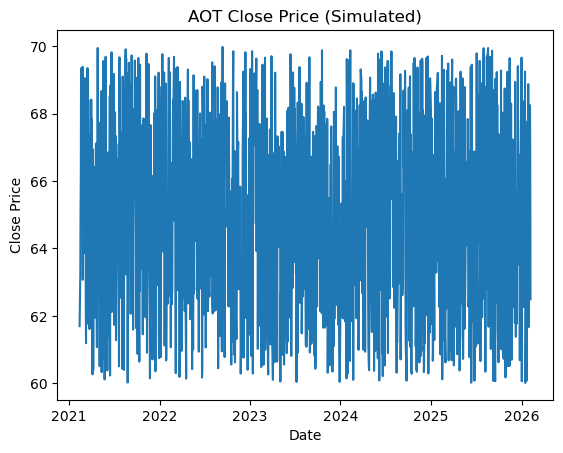

In [36]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["date"], df["close"])
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("AOT Close Price (Simulated)")
plt.show()
